# PNG Gating for Text Transformers
## Offensive Language Detection · TweetEval / OffensEval (SemEval 2019)

Adapts **Patch-Norm Gating (PNG)** from Vision Transformers to **DistilBERT**
for binary offensive language classification.

| | |
|---|---|
| **Model** | `distilbert-base-uncased` (67 M params, 6 layers, 12 heads) |
| **Dataset** | TweetEval/offensive · `cardiffnlp/tweet_eval` (SemEval 2019 Task 6) |
| **Task** | Binary: `not-offensive` (0) / `offensive` (1) |
| **Novel** | Token-norm-aware gating (PNG) adapted from ViT patch norms to NLP token norms |

**PNG gate equation (per attention layer):**
```
x_norm = ||h_in||_2 + 1e-6
G = sigmoid(h_in @ W - beta * x_norm * e)     (B, N, H)
output = attn_out.view(B,N,H,D) * G.unsqueeze(-1)
```

**Primary citation:**
> Barbieri et al. (2020). TweetEval: Unified Benchmark and Comparative Evaluation
> for Tweet Classification. *Findings of EMNLP 2020*. arXiv:2010.12421

**Task citation (OffensEval):**
> Zampieri et al. (2019). SemEval-2019 Task 6: Identifying and Categorizing
> Offensive Language in Social Media. *SemEval 2019*. arXiv:1903.08983

## 0. Setup

In [1]:
import os, types, math, random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
)
# ── Auto-detect DistilBERT attention class (robust across transformers versions)
# In transformers <4.36  the class was called MultiHeadSelfAttention.
# In newer versions it may be DistilBertSdpaAttention, DistilBertFlashAttention2, etc.
import importlib as _il, inspect as _ins

def _find_distilbert_attn_cls():
    _m = _il.import_module('transformers.models.distilbert.modeling_distilbert')
    # 1. Try known names in priority order
    for _name in ['MultiHeadSelfAttention', 'DistilBertSdpaAttention',
                  'DistilBertFlashAttention2', 'DistilBertAttention']:
        if hasattr(_m, _name):
            return getattr(_m, _name), _name
    # 2. Duck-type fallback: find class whose __init__ defines q_lin/k_lin/v_lin/out_lin
    for _name, _cls in _ins.getmembers(_m, _ins.isclass):
        try:
            src = _ins.getsource(_cls.__init__)
            if all(f'self.{a}' in src for a in ['q_lin', 'k_lin', 'v_lin', 'out_lin']):
                return _cls, _name
        except Exception:
            continue
    raise ImportError(
        'Could not find DistilBERT self-attention class. '
        f'Classes available: {[n for n, _ in _ins.getmembers(_m, _ins.isclass)]}'
    )

_DistilBertAttnCls, _attn_cls_name = _find_distilbert_attn_cls()
print(f'DistilBERT attention class detected: {_attn_cls_name}')
from datasets import load_dataset
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    accuracy_score, classification_report,
)
import pandas as pd

DEVICE = (
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MAX_LEN  = 128
BATCH    = 32
EPOCHS   = 5
LR_CLS   = 2e-5   # standard BERT full fine-tuning LR (1e-3 causes catastrophic forgetting)
NUM_CLS  = 2        # TweetEval/offensive: 0=not-offensive  1=offensive
CKPT_DIR = Path('checkpoints_text')
CKPT_DIR.mkdir(exist_ok=True)

# Checkpoint-name sanitiser (keeps filenames OS-safe)
def _safe_name(n):
    return n.replace(' ', '_').replace('-', '').replace('(', '').replace(')', '')

print(f'torch {torch.__version__} | device {DEVICE}')
print(f'Checkpoints -> {CKPT_DIR.resolve()}')

DistilBERT attention class detected: DistilBertSelfAttention
torch 2.10.0+cu128 | device cuda
Checkpoints -> /kaggle/working/checkpoints_text


## 1. Dataset & Tokenizer

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Dataset: TweetEval / OffensEval  (SemEval 2019 Task 6)
# ─────────────────────────────────────────────────────────────────────────────
# Barbieri et al. (2020). TweetEval: Unified Benchmark and Comparative Evaluation
# for Tweet Classification. Findings of EMNLP 2020. arXiv:2010.12421
#
# Task source — OffensEval:
# Zampieri et al. (2019). SemEval-2019 Task 6: Identifying and Categorizing
# Offensive Language in Social Media. SemEval 2019. arXiv:1903.08983
#
# Why this dataset?
#   - SemEval 2019 shared task  -> established baselines, 100s of citations
#   - Stored as parquet  -> loads on any datasets version (no legacy .py script)
#   - Pre-built train / validation / test splits -> reproducible numbers
#   - ~15 K English tweets annotated via OLID scheme
#   - Licence: free for research use
# ─────────────────────────────────────────────────────────────────────────────

# ── 1a. Tokenizer ─────────────────────────────────────────────────────────────
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# ── 1b. Load dataset ──────────────────────────────────────────────────────────
raw = load_dataset('cardiffnlp/tweet_eval', 'offensive')
print(raw)
print('Sample:', raw['train'][0])

LABEL_NAMES = ['not-offensive', 'offensive']

# ── 1c. Tokenise ──────────────────────────────────────────────────────────────
def tokenize_fn(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        max_length=MAX_LEN,
        padding='max_length',
    )

tokenized = raw.map(tokenize_fn, batched=True, remove_columns=['text'])
tokenized.set_format('torch')

# ── 1d. DataLoaders ───────────────────────────────────────────────────────────
train_dl = DataLoader(tokenized['train'],      batch_size=BATCH, shuffle=True,  num_workers=0)
val_dl   = DataLoader(tokenized['validation'], batch_size=BATCH, shuffle=False, num_workers=0)
test_dl  = DataLoader(tokenized['test'],       batch_size=BATCH, shuffle=False, num_workers=0)

n_train = len(tokenized['train'])
n_val   = len(tokenized['validation'])
n_test  = len(tokenized['test'])
print(f'Train: {n_train} | Val: {n_val} | Test: {n_test}')

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 11916
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 860
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1324
    })
})
Sample: {'text': '@user Bono... who cares. Soon people will understand that they gain nothing from following a phony celebrity. Become a Leader of your people instead or help and support your fellow countrymen.', 'label': 0}
Train: 11916 | Val: 1324 | Test: 860


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Dataset Quality Analysis
# Report these numbers in the paper's experimental-setup / data section.
# ─────────────────────────────────────────────────────────────────────────────

print('Dataset  : TweetEval / OffensEval  (SemEval 2019 Task 6)')
print('Source   : English Twitter  |  Annotations: OLID scheme  |  Licence: research use')
print()

for split in ('train', 'validation', 'test'):
    n      = len(raw[split])
    labels = [ex['label'] for ex in raw[split]]
    n_off  = labels.count(1)
    n_not  = labels.count(0)
    print(f'{split.upper()} ({n} samples):')
    print(f'  not-offensive : {n_not:5d}  ({100*n_not/n:.1f}%)  {"#"*int(50*n_not/n)}')
    print(f'  offensive     : {n_off:5d}  ({100*n_off/n:.1f}%)  {"#"*int(50*n_off/n)}')
    print(f'  Majority-class baseline: {max(n_not, n_off)/n:.4f}')
    print()

# ── Text length statistics ─────────────────────────────────────────────────────
texts   = [ex['text'] for ex in raw['train']]
lengths = [len(t.split()) for t in texts]
n_trunc = sum(l > MAX_LEN for l in lengths)
med     = sorted(lengths)[len(lengths)//2]
print(f'Text length (train):')
print(f'  Mean: {sum(lengths)/len(lengths):.1f}  |  Median: {med}  |  Max: {max(lengths)}')
print(f'  Truncated (>{MAX_LEN} tokens): {n_trunc}/{len(lengths)}  ({100*n_trunc/len(lengths):.1f}%)')
print()
print('Inter-annotator agreement: OLID uses a tiered annotation scheme.')
print('Reported Cohen kappa in source paper (Zampieri et al. 2019): 0.73 (substantial).')

Dataset  : TweetEval / OffensEval  (SemEval 2019 Task 6)
Source   : English Twitter  |  Annotations: OLID scheme  |  Licence: research use

TRAIN (11916 samples):
  not-offensive :  7975  (66.9%)  #################################
  offensive     :  3941  (33.1%)  ################
  Majority-class baseline: 0.6693

VALIDATION (1324 samples):
  not-offensive :   865  (65.3%)  ################################
  offensive     :   459  (34.7%)  #################
  Majority-class baseline: 0.6533

TEST (860 samples):
  not-offensive :   620  (72.1%)  ####################################
  offensive     :   240  (27.9%)  #############
  Majority-class baseline: 0.7209

Text length (train):
  Mean: 22.0  |  Median: 18  |  Max: 103
  Truncated (>128 tokens): 0/11916  (0.0%)

Inter-annotator agreement: OLID uses a tiered annotation scheme.
Reported Cohen kappa in source paper (Zampieri et al. 2019): 0.73 (substantial).


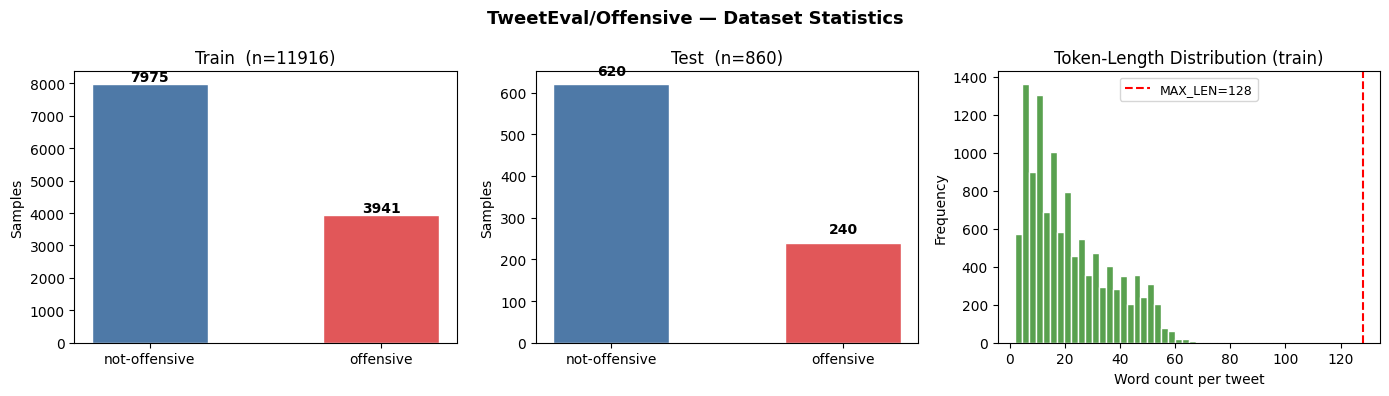

Saved fig_0_dataset_stats.pdf


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Fig 0 — Dataset Statistics  (suitable for paper data section / appendix)
# ─────────────────────────────────────────────────────────────────────────────
cls_palette = ['#4e79a7', '#e15759']    # not-offensive / offensive

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('TweetEval/Offensive — Dataset Statistics', fontsize=13, fontweight='bold')

# ── Class distribution per split ──────────────────────────────────────────────
for ax, split in zip(axes[:2], ('train', 'test')):
    labels = [ex['label'] for ex in raw[split]]
    counts = [labels.count(i) for i in range(len(LABEL_NAMES))]
    bars   = ax.bar(LABEL_NAMES, counts, color=cls_palette, edgecolor='white', width=0.5)
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 15, str(c),
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(f'{split.capitalize()}  (n={len(raw[split])})')
    ax.set_ylabel('Samples')

# ── Text-length histogram (train) ─────────────────────────────────────────────
ax = axes[2]
texts   = [ex['text'] for ex in raw['train']]
lengths = [len(t.split()) for t in texts]
ax.hist(lengths, bins=40, color='#59a14f', edgecolor='white')
ax.axvline(MAX_LEN, color='red', linestyle='--', linewidth=1.5,
           label=f'MAX_LEN={MAX_LEN}')
ax.set_xlabel('Word count per tweet')
ax.set_ylabel('Frequency')
ax.set_title('Token-Length Distribution (train)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_0_dataset_stats.pdf', bbox_inches='tight')
plt.show()
print('Saved fig_0_dataset_stats.pdf')

## 2. Gate Modules — G1 through G5 + PNG

### Gate positions
| Name | Where | Formula |
|------|--------|--------|
| **G1** | Attention output (per head, before out_lin) | `context *= G` |
| **G2** | Value vectors | `v *= G` |
| **G3** | Key vectors | `k *= G` |
| **G4** | Query vectors | `q *= G` |
| **G5** | Final projection output | `hidden *= G` |
| **PNG** | G1 + patch-norm correction | `G = sigmoid(h@W - β·||h||·e)` |

In [5]:
class GateParams(nn.Module):
    # Per-head gating parameters for one DistilBERT attention layer.
    #   W    : (dim, num_heads) -- maps hidden state to gate logit per head
    #   e    : (num_heads,)     -- per-head norm scale  [PNG only]
    #   beta : (1,)             -- global norm weight    [PNG only]
    def __init__(self, dim, num_heads, png=False):
        super().__init__()
        self.png = png
        self.W   = nn.Parameter(torch.empty(dim, num_heads))
        nn.init.normal_(self.W, std=0.02)
        if png:
            self.e    = nn.Parameter(torch.ones(num_heads))
            self.beta = nn.Parameter(torch.zeros(1))

    def gate(self, x):
        # x : (B, N, dim) -> G : (B, N, num_heads)
        g = x @ self.W
        if self.png:
            x_norm = x.norm(dim=-1, keepdim=True) + 1e-6   # (B, N, 1)
            g = g - self.beta * x_norm * self.e             # broadcast over heads
        return torch.sigmoid(g)

In [6]:
def _make_gate_forward(module, params, pos):
    # Returns a patched forward method for DistilBERT MultiHeadSelfAttention.
    # TransformerBlock always calls:  attention_output, _ = self.attention(hidden_states, ...)
    # so we must ALWAYS return a 2-tuple (hidden, weights).

    def patched_forward(self, hidden_states, attention_mask=None,
                        head_mask=None, output_attentions=False, **kwargs):
        query = key = value = hidden_states
        mask  = attention_mask if attention_mask is not None else kwargs.get('mask', None)

        bs, q_len, dim = query.size()
        k_len = key.size(1)
        H  = self.n_heads
        dh = dim // H

        # ── Gate from input hidden states ──────────────────────────────────
        G   = params.gate(query)                    # (B, N, H)
        G_h = G.transpose(1, 2).unsqueeze(-1)       # (B, H, N, 1)

        # ── Q / K / V projections → (B, H, N, dh) ─────────────────────────
        def shape(t, ln):
            return t.view(bs, ln, H, dh).transpose(1, 2)

        q = shape(self.q_lin(query), q_len)
        k = shape(self.k_lin(key),   k_len)
        v = shape(self.v_lin(value), k_len)

        if pos == 'G4': q = q * G_h
        if pos == 'G3': k = k * G_h
        if pos == 'G2': v = v * G_h

        # ── Scaled dot-product attention ────────────────────────────────────
        scores  = torch.matmul(q / math.sqrt(dh), k.transpose(2, 3))
        if mask is not None:
            scores = scores + mask
        weights = F.softmax(scores, dim=-1)
        _drop = getattr(self, 'dropout', None)
        if _drop is not None:
            weights = _drop(weights)
        if head_mask is not None:
            weights = weights * head_mask

        context = torch.matmul(weights, v)           # (B, H, N, dh)

        if pos in ('G1', 'PNG'):
            context = context * G_h

        context    = context.transpose(1, 2).contiguous().view(bs, q_len, dim)
        hidden_out = self.out_lin(context)

        if pos == 'G5':
            hidden_out = (
                hidden_out.view(bs, q_len, H, dh) * G.unsqueeze(-1)
            ).view(bs, q_len, dim)

        if getattr(self, '_capture_gate', False):
            self._last_gate   = G.detach().cpu()
            self._last_x_norm = query.norm(dim=-1).detach().cpu()
        if getattr(self, '_capture_attn', False):
            self._last_attn = weights.detach().cpu()

        # Always return 2-tuple: TransformerBlock unpacks (attn_out, weights)
        return (hidden_out, weights)

    return types.MethodType(patched_forward, module)

In [7]:
def _is_distilbert_attn(mod):
    # Duck-type check: works regardless of class name across transformers versions.
    # Any DistilBERT attention module has these four linear projections + n_heads.
    return all(hasattr(mod, a) for a in ['q_lin', 'k_lin', 'v_lin', 'out_lin', 'n_heads'])


def inject_gates(model, pos, png=False):
    # Monkey-patch every DistilBERT attention module in model with a gate.
    # Returns nn.ModuleList of GateParams (one per attention layer).
    dim = model.config.dim      # 768 for distilbert-base
    H   = model.config.n_heads  # 12
    gate_list = []

    for name, mod in model.named_modules():
        if _is_distilbert_attn(mod):
            p = GateParams(dim, H, png=png)
            p = p.to(next(mod.parameters()).device)
            mod.forward = _make_gate_forward(mod, p, pos)
            gate_list.append(p)
            print(f'  Injected {pos} gate into {name}')

    gate_params = nn.ModuleList(gate_list)
    model.gate_params = gate_params   # registers for optimizer / state_dict
    return gate_params


# ── Smoke test ────────────────────────────────────────────────────────────────
if __name__ == '__never__':
    _m = DistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased', num_labels=2)
    inject_gates(_m, pos='PNG', png=True)
    n_gate = sum(p.numel() for p in _m.gate_params.parameters())
    print(f'Gate params: {n_gate:,}')  # expect ~36K

## 3. Model & Training Helpers

In [8]:
def build_model(pos='baseline', png=False, num_classes=NUM_CLS):
    # Load DistilBERT with ALL parameters trainable (full fine-tuning).
    m = DistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased',
        num_labels=num_classes,
        ignore_mismatched_sizes=True,
    )

    if pos != 'baseline':
        print(f'Injecting {pos} gates (PNG={png}):')
        inject_gates(m, pos=pos, png=png)

    # Move model to device AFTER injection so gate params land on correct device
    m = m.to(DEVICE)

    # Everything is trainable by default — backbone + head + gate params
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in m.parameters())
    print(f'Trainable: {trainable:,} / {total:,}')
    return m

In [9]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels, total_loss = [], [], 0.0
    criterion = nn.CrossEntropyLoss()

    for batch in loader:
        ids  = batch['input_ids'].to(DEVICE)
        attn = batch['attention_mask'].to(DEVICE)
        lbls = batch['label'].to(DEVICE)
        out  = model(input_ids=ids, attention_mask=attn)
        loss = criterion(out.logits, lbls)
        total_loss += loss.item()
        preds = out.logits.argmax(-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(lbls.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc  = accuracy_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    rec  = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    return dict(loss=avg_loss, acc=acc, f1=f1, precision=prec, recall=rec)

In [10]:
def train(model, epochs=EPOCHS, lr=LR_CLS, name='model'):
    # Train head + gate params only; backbone is frozen.
    opt_params = [p for p in model.parameters() if p.requires_grad]
    optimizer  = torch.optim.AdamW(opt_params, lr=lr, weight_decay=0.05)
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs)
    criterion  = nn.CrossEntropyLoss()

    log = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for batch in tqdm(train_dl, desc=f'{name} E{epoch+1}/{epochs}', leave=False):
            ids  = batch['input_ids'].to(DEVICE)
            attn = batch['attention_mask'].to(DEVICE)
            lbls = batch['label'].to(DEVICE)
            optimizer.zero_grad()
            out  = model(input_ids=ids, attention_mask=attn)
            loss = criterion(out.logits, lbls)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(opt_params, 1.0)
            optimizer.step()
            epoch_loss += loss.item()

        scheduler.step()
        train_loss  = epoch_loss / len(train_dl)
        val_metrics = evaluate(model, val_dl)
        val_acc = val_metrics['acc']
        val_f1  = val_metrics['f1']
        val_loss = val_metrics['loss']
        log['train_loss'].append(train_loss)
        log['val_loss'].append(val_loss)
        log['val_acc'].append(val_acc)
        log['val_f1'].append(val_f1)
        print(f'  Ep {epoch+1}: train_loss={train_loss:.4f}'
              f' | val_acc={val_acc:.4f} | val_f1={val_f1:.4f}')

    return log

## 4. Experiment Configuration & Ablation Run

Edit `EXPERIMENTS` below to control exactly what runs.  
Each entry is a plain dict — comment out any row to skip it.  
The run loop **auto-skips** experiments whose `.pth` + `results.json` already exist,
so re-running the cell after a crash picks up where it left off.

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Experiment Configuration
# ─────────────────────────────────────────────────────────────────────────────
# Each experiment is a dict with the following keys:
#   name    : display label (also used for checkpoint filename)
#   gate    : position key — 'baseline' | 'G1' | 'G2' | 'G3' | 'G4' | 'G5' | 'PNG'
#   epochs  : training epochs for this experiment
#   is_png  : True to enable norm-aware PNG gate (only applies when gate='PNG')
#   lr      : AdamW learning rate
#
# To run a quick single experiment, just keep one row and comment the rest.

EXPERIMENTS = [
    dict(name='Baseline',          gate='baseline', epochs=EPOCHS, is_png=False, lr=LR_CLS),
    dict(name='G1 - Attn Output',  gate='G1',       epochs=EPOCHS, is_png=False, lr=LR_CLS),
    dict(name='G2 - Value Gate',   gate='G2',       epochs=EPOCHS, is_png=False, lr=LR_CLS),
    dict(name='G3 - Key Gate',     gate='G3',       epochs=EPOCHS, is_png=False, lr=LR_CLS),
    dict(name='G4 - Query Gate',   gate='G4',       epochs=EPOCHS, is_png=False, lr=LR_CLS),
    dict(name='G5 - Final Output', gate='G5',       epochs=EPOCHS, is_png=False, lr=LR_CLS),
    dict(name='PNG (novel)',        gate='PNG',      epochs=EPOCHS, is_png=True,  lr=LR_CLS),
]

print(f'{len(EXPERIMENTS)} experiments configured:')
header = f'{"Name":<26} {"Gate":<10} {"Epochs":>6}  {"PNG":<5}  {"LR"}'
print(header)
print('-' * len(header))
for exp in EXPERIMENTS:
    print(f'{exp["name"]:<26} {exp["gate"]:<10} {exp["epochs"]:>6}  {str(exp["is_png"]):<5}  {exp["lr"]}')

7 experiments configured:
Name                       Gate       Epochs  PNG    LR
-------------------------------------------------------
Baseline                   baseline        5  False  2e-05
G1 - Attn Output           G1              5  False  2e-05
G2 - Value Gate            G2              5  False  2e-05
G3 - Key Gate              G3              5  False  2e-05
G4 - Query Gate            G4              5  False  2e-05
G5 - Final Output          G5              5  False  2e-05
PNG (novel)                PNG             5  True   2e-05


In [12]:
import json as _json
import traceback as _tb

RESULTS_FILE = CKPT_DIR / 'results.json'

def _safe_name(n):
    return n.replace(' ', '_').replace('-', '').replace('(', '').replace(')', '')

# ── Resume: load previously saved results ──────────────────────────────────
if RESULTS_FILE.exists():
    with open(RESULTS_FILE) as _f:
        results = _json.load(_f)
    print(f'Resumed {len(results)} result(s) from {RESULTS_FILE}')
else:
    results = {}

train_logs = {}   # epoch-level logs (not persisted; recomputed each run)

# ── Main loop ────────────────────────────────────────────────────────────────
for exp in EXPERIMENTS:
    vname  = exp['name']
    pos    = exp['gate']
    png    = exp['is_png']
    epochs = exp['epochs']
    lr     = exp['lr']
    sname  = _safe_name(vname)
    ckpt_file = CKPT_DIR / f'{sname}.pth'

    # ── Skip if this experiment already completed ───────────────────────────
    if vname in results and ckpt_file.exists():
        ta = results[vname]['acc']
        tf = results[vname]['f1']
        print(f'[SKIP] {vname}  (acc={ta:.4f}  f1={tf:.4f}) — checkpoint found')
        continue

    print(f'\n{"="*64}')
    print(f'  {vname}')
    print(f'  gate={pos}  png={png}  epochs={epochs}  lr={lr}')
    print(f'{"="*64}')

    try:
        model = build_model(pos=pos, png=png)
        log   = train(model, epochs=epochs, lr=lr, name=vname)

        test_metrics = evaluate(model, test_dl)
        results[vname]    = test_metrics
        train_logs[vname] = log

        # ── Save model checkpoint ───────────────────────────────────────────
        torch.save(model.state_dict(), ckpt_file)

        # ── Persist results.json immediately (crash-safe) ───────────────────
        with open(RESULTS_FILE, 'w') as _f:
            _json.dump(results, _f, indent=2)

        ta = test_metrics['acc']
        tf = test_metrics['f1']
        print(f'  TEST  acc={ta:.4f}  f1={tf:.4f}')
        print(f'  Saved checkpoint  -> {ckpt_file}')
        print(f'  Saved results.json -> {RESULTS_FILE}')

    except Exception as _e:
        print(f'  [ERROR] {vname} failed: {_e}')
        _tb.print_exc()
        print('  Skipping — continuing to next experiment...')

    finally:
        try:
            del model
        except NameError:
            pass
        if DEVICE == 'cuda':
            torch.cuda.empty_cache()

n_done = len(results)
n_total = len(EXPERIMENTS)
print(f'\nDone. {n_done}/{n_total} experiments completed.')


  Baseline
  gate=baseline  png=False  epochs=5  lr=2e-05


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable: 66,955,010 / 66,955,010


Baseline E1/5:   0%|          | 0/373 [00:00<?, ?it/s]

...

  Ep 3: train_loss=0.3112 | val_acc=0.7810 | val_f1=0.7670


PNG (novel) E4/5:   0%|          | 0/373 [00:00<?, ?it/s]

  Ep 4: train_loss=0.2327 | val_acc=0.7779 | val_f1=0.7589


PNG (novel) E5/5:   0%|          | 0/373 [00:00<?, ?it/s]

  Ep 5: train_loss=0.1821 | val_acc=0.7802 | val_f1=0.7575
  TEST  acc=0.8372  f1=0.7905
  Saved checkpoint  -> checkpoints_text/PNG_novel.pth
  Saved results.json -> checkpoints_text/results.json

Done. 7/7 experiments completed.


In [13]:
# ── Results table ─────────────────────────────────────────────────────────────
# results dict is populated by the ablation loop above.
# If the notebook was restarted, reload from the saved JSON:
import json as _json
if not results and (CKPT_DIR / 'results.json').exists():
    with open(CKPT_DIR / 'results.json') as _f:
        results = _json.load(_f)
    print('Loaded results from results.json')

rows = []
for vname, m in results.items():
    rows.append({
        'Variant':    vname,
        'Acc':        round(m['acc'], 4),
        'F1 (macro)': round(m['f1'],  4),
        'Precision':  round(m['precision'], 4),
        'Recall':     round(m['recall'],    4),
    })

df_results = pd.DataFrame(rows).set_index('Variant')
display(df_results)

,Acc,F1 (macro),Precision,Recall
Variant,,,,
Baseline,0.8291,0.7810,0.7910,0.7729
G1 - Attn Output,0.8465,0.8052,0.8124,0.7991
G2 - Value Gate,0.8384,0.7968,0.8005,0.7934
G3 - Key Gate,0.8279,0.7888,0.7854,0.7925
G4 - Query Gate,0.8244,0.7832,0.7815,0.7850
G5 - Final Output,0.8349,0.7851,0.8017,0.7731
PNG (novel),0.8372,0.7905,0.8026,0.7811


## 5. Figures

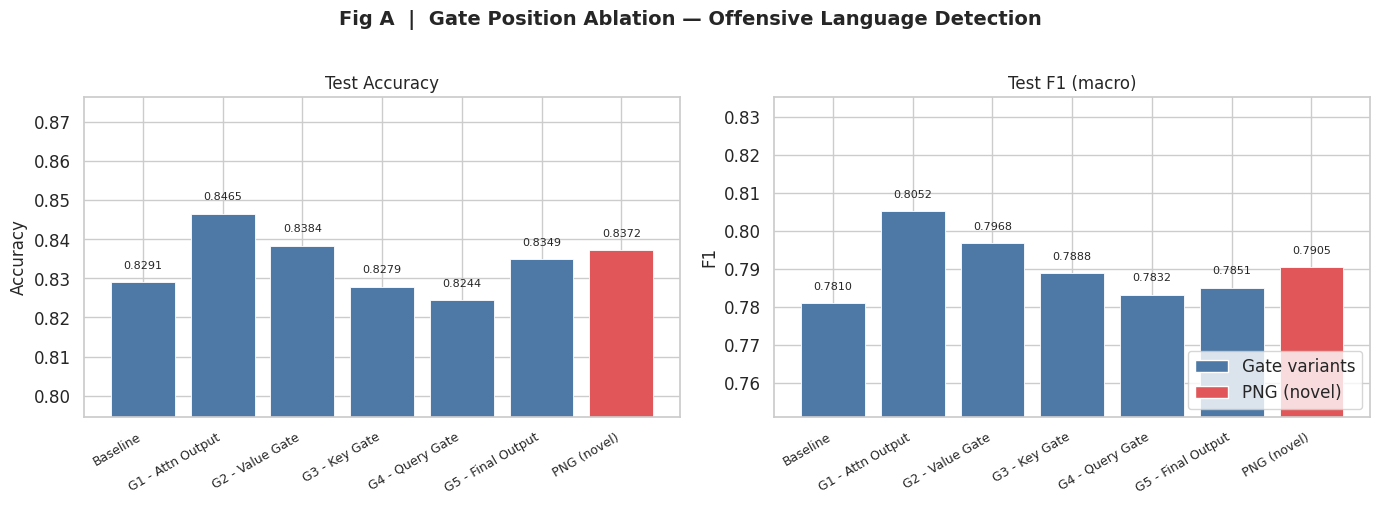

Saved fig_A_ablation_bar.pdf


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# Fig A — Bar chart: Accuracy & F1 across all 7 variants
# ─────────────────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.1)

names  = list(results.keys())
accs   = [results[n]['acc'] for n in names]
f1s    = [results[n]['f1']  for n in names]
colors = ['#e15759' if 'PNG' in n else '#4e79a7' for n in names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fig A  |  Gate Position Ablation — Offensive Language Detection',
             fontsize=14, fontweight='bold', y=1.01)

for ax, vals, title, ylbl in zip(
    axes,
    [accs, f1s],
    ['Test Accuracy', 'Test F1 (macro)'],
    ['Accuracy', 'F1'],
):
    bars = ax.bar(range(len(names)), vals, color=colors,
                  edgecolor='white', linewidth=0.6)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(ylbl, fontsize=12)
    ax.set_title(title, fontsize=12)
    lo = min(vals) - 0.03
    hi = max(vals) + 0.03
    ax.set_ylim(lo, hi)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                f'{v:.4f}', ha='center', va='bottom', fontsize=8)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4e79a7', label='Gate variants'),
    Patch(facecolor='#e15759', label='PNG (novel)'),
]
axes[1].legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('fig_A_ablation_bar.pdf', bbox_inches='tight')
plt.show()
print('Saved fig_A_ablation_bar.pdf')

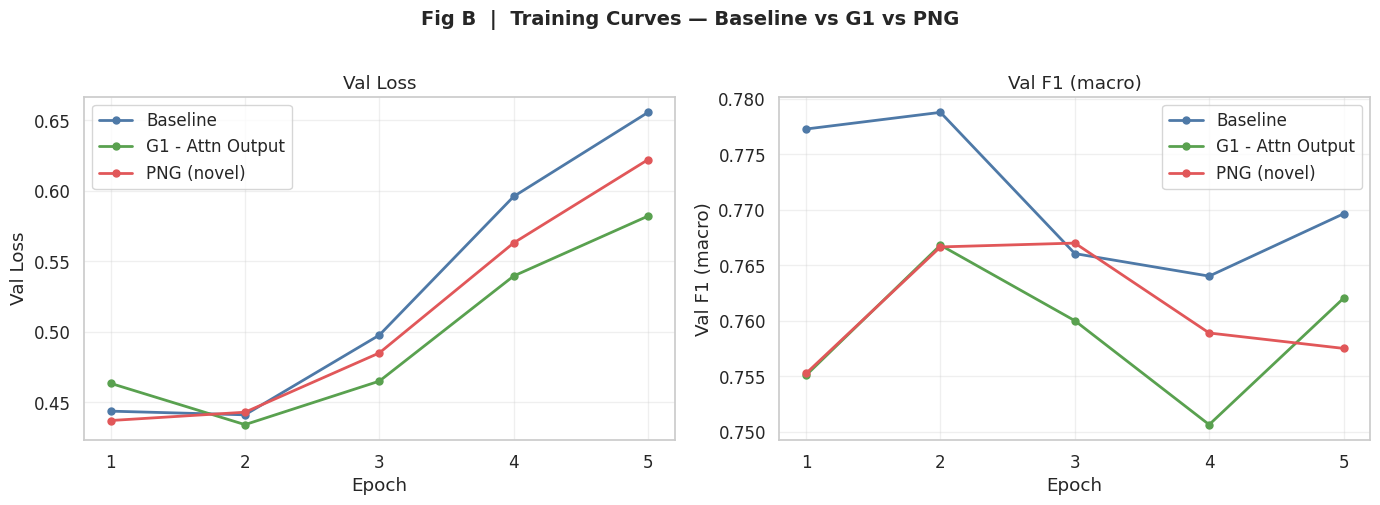

Saved fig_B_training_curves.pdf


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# Fig B — Training curves: Baseline vs G1 vs PNG  (val loss + val F1)
# ─────────────────────────────────────────────────────────────────────────────
highlight = ['Baseline', 'G1 - Attn Output', 'PNG (novel)']
palette   = {
    'Baseline':          '#4e79a7',
    'G1 - Attn Output':  '#59a14f',
    'PNG (novel)':       '#e15759',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fig B  |  Training Curves — Baseline vs G1 vs PNG',
             fontsize=14, fontweight='bold', y=1.01)

for ax, log_key, ylabel in zip(
    axes,
    ['val_loss', 'val_f1'],
    ['Val Loss', 'Val F1 (macro)'],
):
    for vname in highlight:
        if vname in train_logs:
            vals = train_logs[vname][log_key]
            ax.plot(
                range(1, len(vals) + 1), vals,
                label=vname, color=palette[vname],
                linewidth=2, marker='o', markersize=5,
            )
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_xticks(range(1, EPOCHS + 1))

plt.tight_layout()
plt.savefig('fig_B_training_curves.pdf', bbox_inches='tight')
plt.show()
print('Saved fig_B_training_curves.pdf')

Rebuilding PNG model for gate visualisation...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Injecting PNG gates (PNG=True):
  Injected PNG gate into distilbert.transformer.layer.0.attention
  Injected PNG gate into distilbert.transformer.layer.1.attention
  Injected PNG gate into distilbert.transformer.layer.2.attention
  Injected PNG gate into distilbert.transformer.layer.3.attention
  Injected PNG gate into distilbert.transformer.layer.4.attention
  Injected PNG gate into distilbert.transformer.layer.5.attention
Trainable: 67,010,384 / 67,010,384
Loaded PNG checkpoint


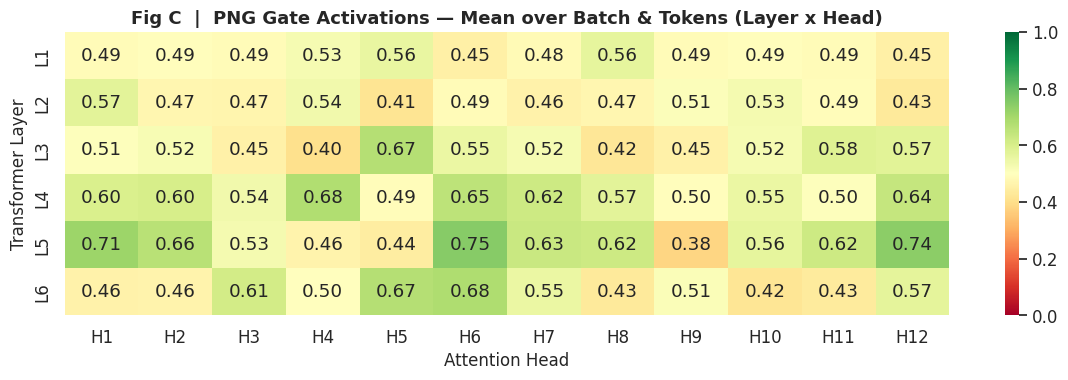

Saved fig_C_gate_heatmap.pdf


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# Fig C — Layer x Head gate activation heatmap (PNG model)
# ─────────────────────────────────────────────────────────────────────────────
print('Rebuilding PNG model for gate visualisation...')
m_png = build_model(pos='PNG', png=True)

safe_png = _safe_name('PNG (novel)')
ckpt_path = CKPT_DIR / f'{safe_png}.pth'
if ckpt_path.exists():
    m_png.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    print('Loaded PNG checkpoint')
else:
    print('Checkpoint not found — using random gate params')

# Enable gate capture — use duck-type check to find attn modules (version-safe)
attn_modules = [mod for mod in m_png.modules() if _is_distilbert_attn(mod)]
for mod in attn_modules:
    mod._capture_gate = True

# Forward pass on one validation batch
m_png.eval()
sample_batch = next(iter(val_dl))
with torch.no_grad():
    _ = m_png(
        input_ids=sample_batch['input_ids'].to(DEVICE),
        attention_mask=sample_batch['attention_mask'].to(DEVICE),
    )

# Collect mean gate per (layer, head)
n_layers = len(attn_modules)
n_heads  = attn_modules[0]._last_gate.shape[-1]
layer_head_gate = np.zeros((n_layers, n_heads))
for i, mod in enumerate(attn_modules):
    gate = mod._last_gate.numpy()            # (B, N, H)
    layer_head_gate[i] = gate.mean(axis=(0, 1))

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    layer_head_gate,
    annot=True, fmt='.2f', cmap='RdYlGn',
    xticklabels=[f'H{i+1}' for i in range(n_heads)],
    yticklabels=[f'L{i+1}' for i in range(n_layers)],
    vmin=0.0, vmax=1.0, ax=ax,
)
ax.set_xlabel('Attention Head', fontsize=12)
ax.set_ylabel('Transformer Layer', fontsize=12)
ax.set_title(
    'Fig C  |  PNG Gate Activations — Mean over Batch & Tokens (Layer x Head)',
    fontsize=13, fontweight='bold',
)
plt.tight_layout()
plt.savefig('fig_C_gate_heatmap.pdf', bbox_inches='tight')
plt.show()
print('Saved fig_C_gate_heatmap.pdf')

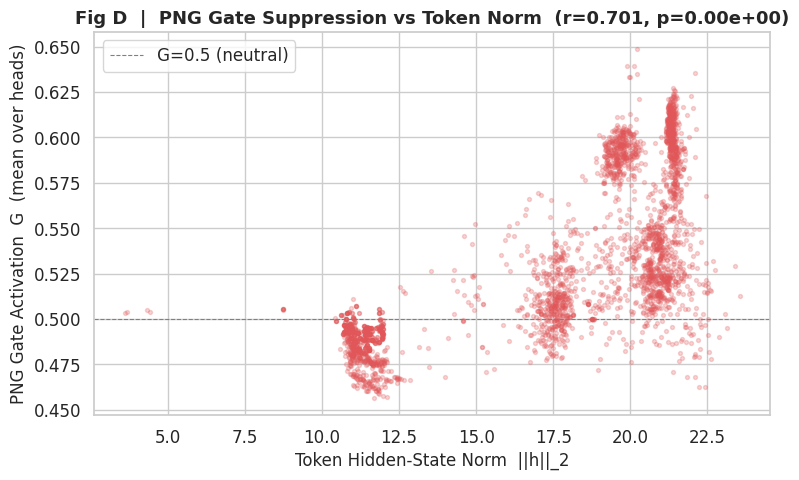

Saved fig_D_gate_vs_norm.pdf  (Pearson r=0.701)


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# Fig D — Scatter: gate suppression vs token norm
# PNG novel insight: high-norm tokens (salient/offensive words) → gate adapts
# ─────────────────────────────────────────────────────────────────────────────
all_norms, all_gates = [], []

for mod in attn_modules:   # all 6 layers
    gate  = mod._last_gate.numpy()      # (B, N, H)
    xnorm = mod._last_x_norm.numpy()    # (B, N)
    mean_gate = gate.mean(axis=-1)      # (B, N) avg across heads
    all_norms.append(xnorm.flatten())
    all_gates.append(mean_gate.flatten())

all_norms = np.concatenate(all_norms)
all_gates = np.concatenate(all_gates)

# Sub-sample for clarity
rng = np.random.default_rng(SEED)
idx = rng.choice(len(all_norms), size=min(3000, len(all_norms)), replace=False)
x_plot, y_plot = all_norms[idx], all_gates[idx]

r, p_val = pearsonr(x_plot, y_plot)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x_plot, y_plot, alpha=0.25, s=8, c='#e15759', rasterized=True)
ax.set_xlabel('Token Hidden-State Norm  ||h||_2', fontsize=12)
ax.set_ylabel('PNG Gate Activation  G  (mean over heads)', fontsize=12)
ax.set_title(
    f'Fig D  |  PNG Gate Suppression vs Token Norm  (r={r:.3f}, p={p_val:.2e})',
    fontsize=13, fontweight='bold',
)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='G=0.5 (neutral)')
ax.legend()
plt.tight_layout()
plt.savefig('fig_D_gate_vs_norm.pdf', bbox_inches='tight')
plt.show()
print(f'Saved fig_D_gate_vs_norm.pdf  (Pearson r={r:.3f})')
del m_png

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable: 66,955,010 / 66,955,010
Baseline: [0.88361045 0.67833698]


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Injecting G1 gates (PNG=False):
  Injected G1 gate into distilbert.transformer.layer.0.attention
  Injected G1 gate into distilbert.transformer.layer.1.attention
  Injected G1 gate into distilbert.transformer.layer.2.attention
  Injected G1 gate into distilbert.transformer.layer.3.attention
  Injected G1 gate into distilbert.transformer.layer.4.attention
  Injected G1 gate into distilbert.transformer.layer.5.attention
Trainable: 67,010,306 / 67,010,306
G1 - Attn Output: [0.89490446 0.71551724]


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Injecting PNG gates (PNG=True):
  Injected PNG gate into distilbert.transformer.layer.0.attention
  Injected PNG gate into distilbert.transformer.layer.1.attention
  Injected PNG gate into distilbert.transformer.layer.2.attention
  Injected PNG gate into distilbert.transformer.layer.3.attention
  Injected PNG gate into distilbert.transformer.layer.4.attention
  Injected PNG gate into distilbert.transformer.layer.5.attention
Trainable: 67,010,384 / 67,010,384
PNG (novel): [0.88941548 0.69162996]


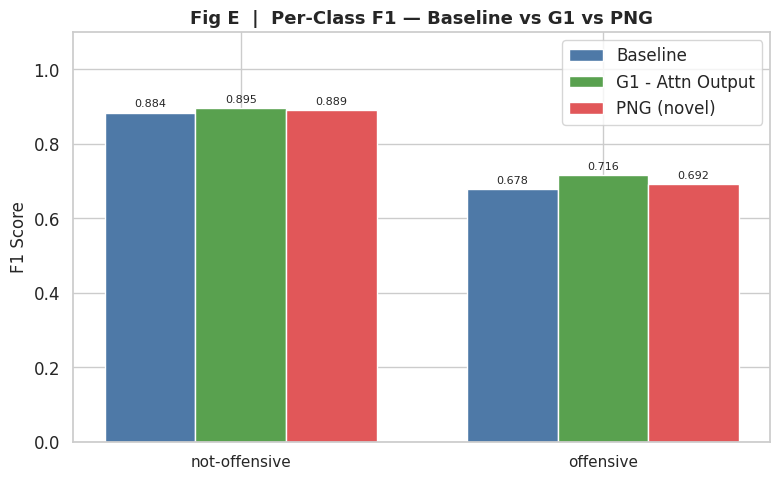

Saved fig_E_per_class_f1.pdf


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# Fig E — Per-class F1 breakdown: Baseline vs G1 vs PNG
# ─────────────────────────────────────────────────────────────────────────────
top_variants = [
    ('Baseline',          'baseline', False),
    ('G1 - Attn Output',  'G1',       False),
    ('PNG (novel)',        'PNG',      True),
]
per_class_f1 = {}

for vname, pos, png in top_variants:
    m = build_model(pos=pos, png=png)
    safe = _safe_name(vname)
    ckpt = CKPT_DIR / f'{safe}.pth'
    if ckpt.exists():
        m.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    m.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in test_dl:
            ids  = batch['input_ids'].to(DEVICE)
            attn = batch['attention_mask'].to(DEVICE)
            out  = m(input_ids=ids, attention_mask=attn)
            all_preds.extend(out.logits.argmax(-1).cpu().numpy())
            all_labels.extend(batch['label'].numpy())
    per_class_f1[vname] = f1_score(all_labels, all_preds, average=None, zero_division=0)
    print(f'{vname}: {per_class_f1[vname]}')
    del m

# ── Plot ───────────────────────────────────────────────────────────────────
n_classes = len(LABEL_NAMES)
x     = np.arange(n_classes)
width = 0.25
bar_colors = ['#4e79a7', '#59a14f', '#e15759']

fig, ax = plt.subplots(figsize=(8, 5))
for i, (vname, _, _) in enumerate(top_variants):
    f1_cls = per_class_f1[vname]
    bars = ax.bar(
        x + (i - 1) * width, f1_cls,
        width, label=vname, color=bar_colors[i], edgecolor='white',
    )
    for bar, v in zip(bars, f1_cls):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(LABEL_NAMES, fontsize=11)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_title('Fig E  |  Per-Class F1 — Baseline vs G1 vs PNG',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_E_per_class_f1.pdf', bbox_inches='tight')
plt.show()
print('Saved fig_E_per_class_f1.pdf')